# 07 - Stage 4b Feature Extraction QA

Visual checks on the per-tile feature parquets in `dataset/features/{ObsId}.parquet`.

Stage 4b emits 9 feature families (PLAN_Stage4b.md §3):
1. **`intensity_stats`** -- mean / std / percentiles + skewness + kurtosis (10 cols).
2. **`glcm`** -- 6 properties × (1-3 distances), rotation-averaged. Scale-dependent
   quantization (8 / 16 / 16 / 32 levels). 18 cols (NaN-padded at S=8).
3. **`gradient`** -- Sobel magnitude mean/std/p90/p99 + direction circular variance (5 cols).
4. **`shadow_fraction`** + `bright_cap_fraction` -- per-image DN-mode-derived thresholds (3 cols).
5. **`lbp`** -- rotation-invariant uniform LBP histogram, P=8 R=1 (10 cols).
6. **`lacunarity`** -- gliding-box on shadow mask, S>=32 only (2 cols).
7. **`subtile_variance`** -- variance of (S/2)-block means, S>=16 only (1 col).
8. **`canny_edges`** -- density + orientation entropy, S>=16 only (2 cols).
9. **`context_patch`** -- bundled (n, 32, 32) and (n, 64, 64) uint8 stacks per ObsId.

Plus `valid_pixel_fraction` (operational; should always be 1.0 by Stage 4 eligibility).

All real logic lives in `src/features.py`. This notebook only loads the cached parquets
and plots.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import manifest as M
from src.config import load_config
from src.features import (
    FEATURES_SUBDIR, load_context_patches, load_features, load_features_provenance,
)
from src.labeling import LABELS_SUBDIR, load_labels, load_provenance

FIG_DIR = REPO_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config(REPO_ROOT / 'config.yaml')
manifest_df = M.load_manifest(cfg.manifest_path)

obs_ids = []
for obs in manifest_df['ObsId']:
    if (cfg.output_dir / FEATURES_SUBDIR / f'{obs}.parquet').exists():
        obs_ids.append(obs)
print(f'{len(obs_ids)} ObsIds with Stage 4b outputs: {obs_ids}')


9 ObsIds with Stage 4b outputs: ['ESP_055714_2270', 'ESP_054857_2270', 'ESP_069669_2220', 'ESP_071093_2210', 'ESP_047976_2020', 'ESP_056165_2200', 'ESP_075577_2105', 'ESP_039820_1750', 'ESP_065711_1545']


## Per-image timing summary

How long Stage 4b takes per image, broken down by family. GLCM dominates -- the per-tile
loop through skimage.graycomatrix. Everything else is window-once vectorised reductions.


                 n_tiles  fam_intensity_stats  fam_gradient  fam_shadow_fraction  fam_lbp  fam_subtile_variance  fam_canny_edges  fam_lacunarity  fam_glcm  total_modeled
ObsId                                                                                                                                                                    
ESP_055714_2270   100558                 1.08          0.58                 0.33     0.22                  0.05             0.61            0.67     22.07          27.13
ESP_054857_2270    48875                 0.56          0.27                 0.15     0.11                  0.03             0.30            0.34     11.04          13.71
ESP_069669_2220    96354                 1.18          0.57                 0.33     0.23                  0.06             0.45            0.80     27.56          32.71
ESP_071093_2210    73958                 0.81          0.40                 0.28     0.18                  0.03             0.36            0.42     1

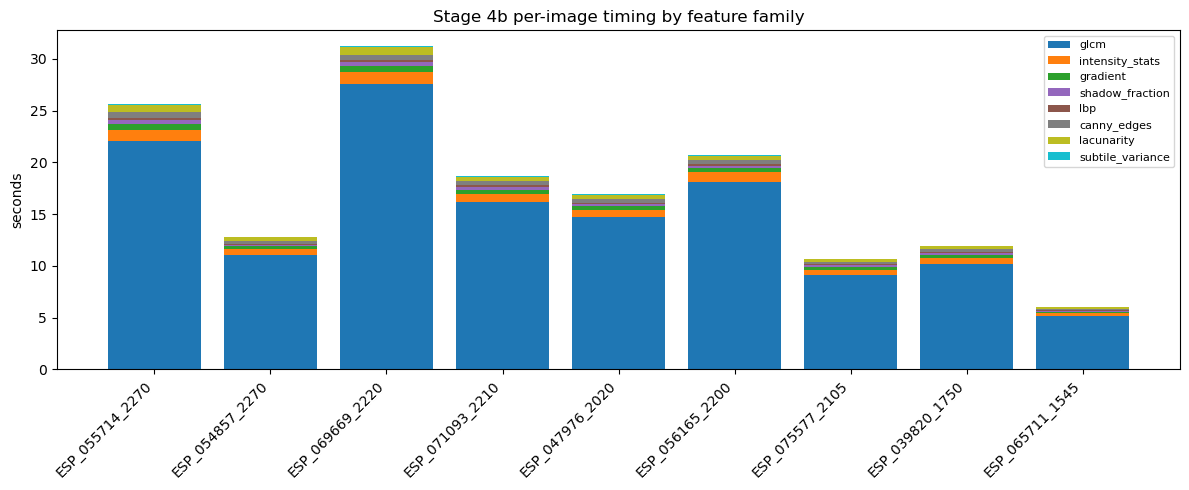

In [2]:
timing_rows = []
for obs in obs_ids:
    prov = load_features_provenance(obs, cfg.output_dir)
    img_t = prov.get('timings_per_image_seconds', {})
    scale_t = prov.get('timings_per_scale_seconds', {})
    row = {'ObsId': obs, 'n_tiles': prov['n_tiles_total']}
    for k, v in img_t.items():
        row[f'img_{k}'] = float(v)
    families = ['intensity_stats', 'gradient', 'shadow_fraction', 'lbp',
                'subtile_variance', 'canny_edges', 'lacunarity', 'glcm']
    for fam in families:
        row[f'fam_{fam}'] = float(sum(scale_t.get(s, {}).get(fam, 0.0) for s in scale_t))
    row['total_modeled'] = sum(row[k] for k in row if k.startswith('img_') or k.startswith('fam_'))
    timing_rows.append(row)
timing_df = pd.DataFrame(timing_rows).set_index('ObsId')
display_cols = ['n_tiles'] + [c for c in timing_df.columns if c.startswith('fam_')] + ['total_modeled']
print(timing_df[display_cols].round(2).to_string())

# Stacked bar chart of per-family time per image.
fig, ax = plt.subplots(figsize=(12, 5))
families = ['glcm', 'intensity_stats', 'gradient', 'shadow_fraction', 'lbp',
            'canny_edges', 'lacunarity', 'subtile_variance']
bottom = np.zeros(len(timing_df))
colors = plt.cm.tab10(np.linspace(0, 1, len(families)))
for fam, c in zip(families, colors):
    col = f'fam_{fam}'
    if col in timing_df.columns:
        ax.bar(timing_df.index, timing_df[col], bottom=bottom, label=fam, color=c)
        bottom += timing_df[col].to_numpy()
ax.set_ylabel('seconds')
ax.set_title('Stage 4b per-image timing by feature family')
ax.legend(fontsize=8, loc='upper right')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()
fig.savefig(FIG_DIR / '07_timing_per_family.png', dpi=110)
plt.show()


## Per-image DN thresholds

The DN-mode + offset shadow detector picks a modal DN per image (most-frequent pixel value)
and derives shadow / strict-shadow / bright-cap thresholds as offsets from it. Boulder-rich
darker scenes get lower modes; boulder-poor brighter scenes get higher modes. The thresholds
shift with the mode so 'shadow' means the same thing relative to image brightness in every
scene -- the property that motivated the AskUserQuestion 2026-05-23 = DN-mode choice over
the simpler image-percentile alternative.


In [3]:
rows = []
for obs in obs_ids:
    prov = load_features_provenance(obs, cfg.output_dir)
    dn = prov['dn_thresholds']
    rows.append({'ObsId': obs,
                 'mode': dn['mode'], 'shadow': dn['shadow'],
                 'strict': dn['shadow_strict'], 'bright': dn['bright'],
                 'method': dn['method'],
                 'label': manifest_df.set_index('ObsId').loc[obs, 'BoulderLabel']})
dn_df = pd.DataFrame(rows).set_index('ObsId')
print(dn_df.to_string())


                 mode  shadow  strict  bright          method         label
ObsId                                                                      
ESP_055714_2270   115      95      80     145  dn_mode_offset  Boulder rich
ESP_054857_2270   156     136     121     186  dn_mode_offset  Boulder rich
ESP_069669_2220    77      57      42     107  dn_mode_offset  Boulder rich
ESP_071093_2210   129     109      94     159  dn_mode_offset  Boulder rich
ESP_047976_2020   135     115     100     165  dn_mode_offset  Boulder rich
ESP_056165_2200   166     146     131     196  dn_mode_offset  Boulder poor
ESP_075577_2105   117      97      82     147  dn_mode_offset  Boulder poor
ESP_039820_1750   139     119     104     169  dn_mode_offset       unknown
ESP_065711_1545    87      67      52     117  dn_mode_offset       unknown


## Per-image feature heatmaps (finest scale)

Four feature maps side-by-side per ObsId at finest scale (S=8 px = 40 m):
- `intensity_mean` -- raw CTX brightness average per tile.
- `glcm_contrast_d1` -- GLCM contrast at d=1 (8-level quantization). Texture energy.
- `grad_mag_mean` -- mean Sobel gradient magnitude. Edge density proxy.
- `shadow_fraction` -- fraction of pixels below DN-mode-derived shadow threshold.

Boulder-rich images should show strong contrast/gradient/shadow signals in their textured
ejecta region; boulder-poor images should be uniform across all four panels.


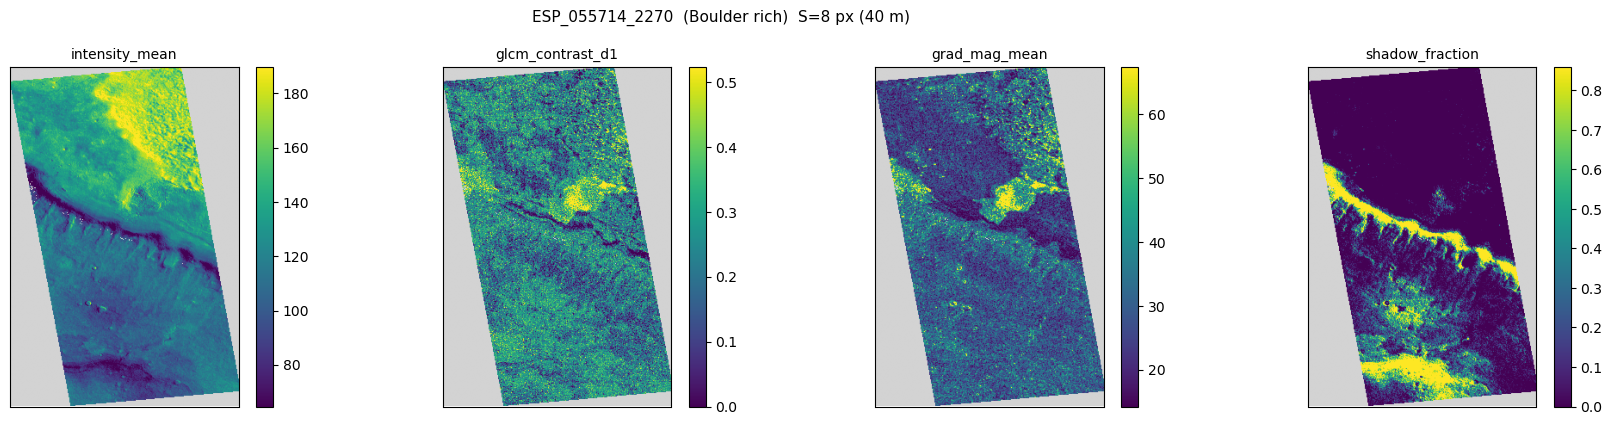

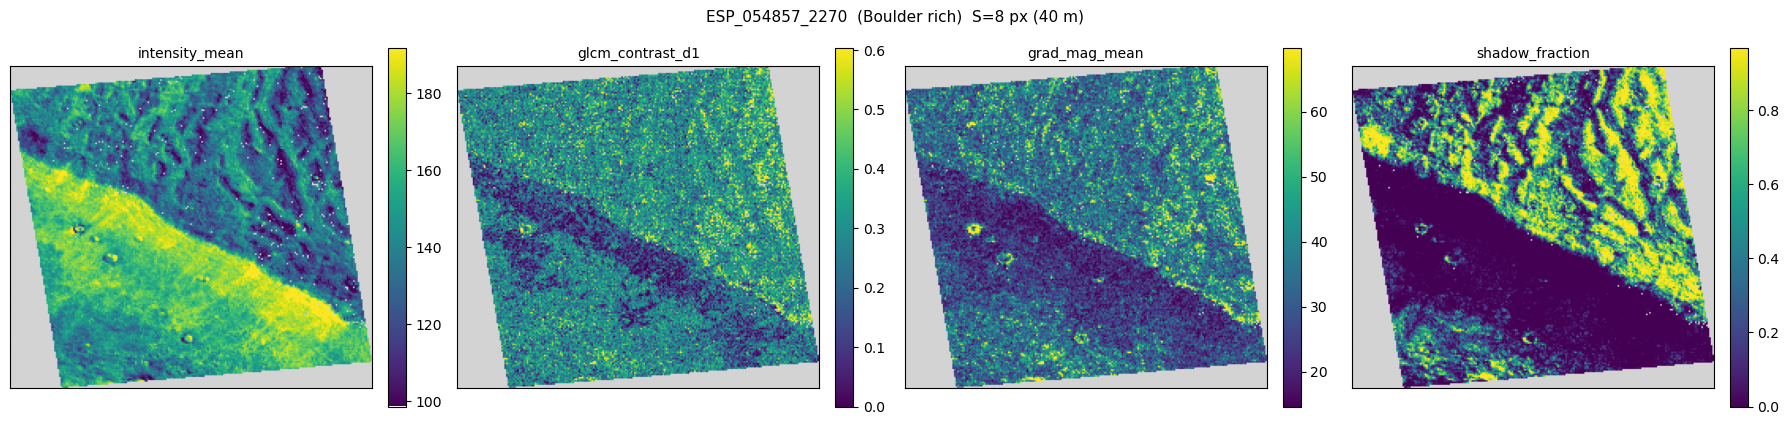

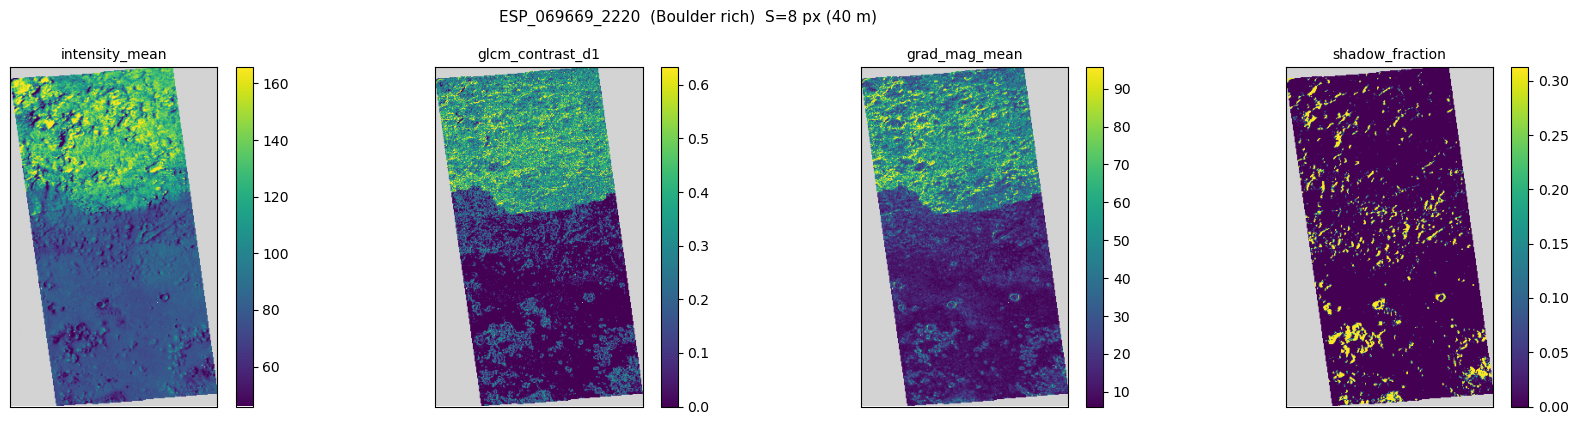

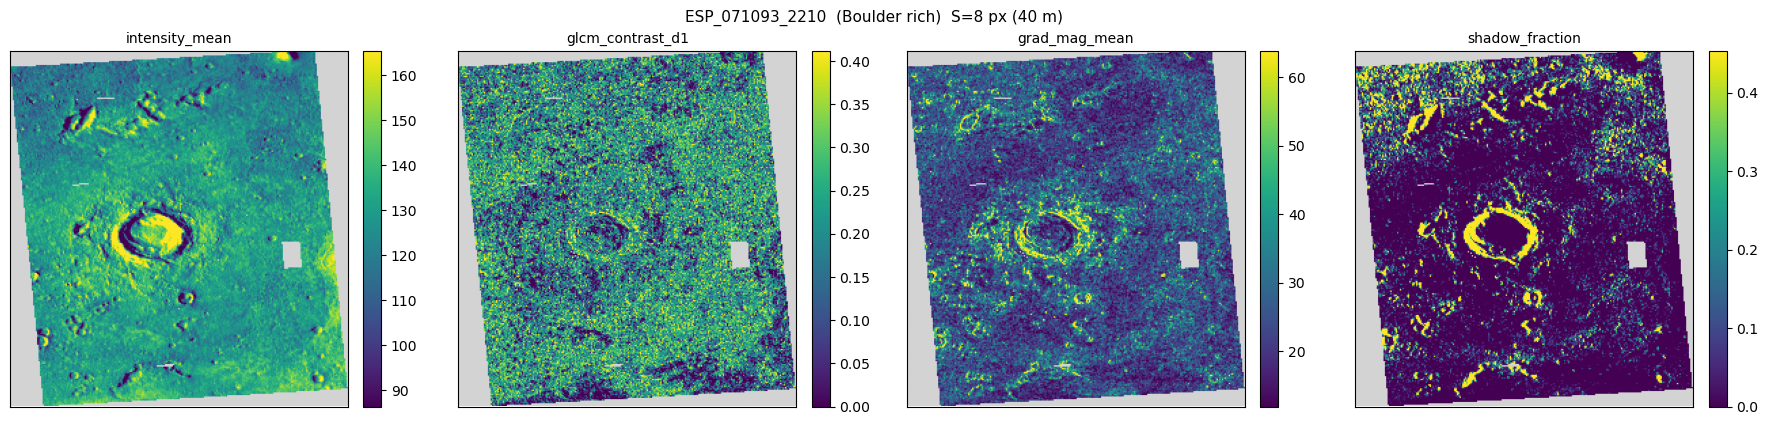

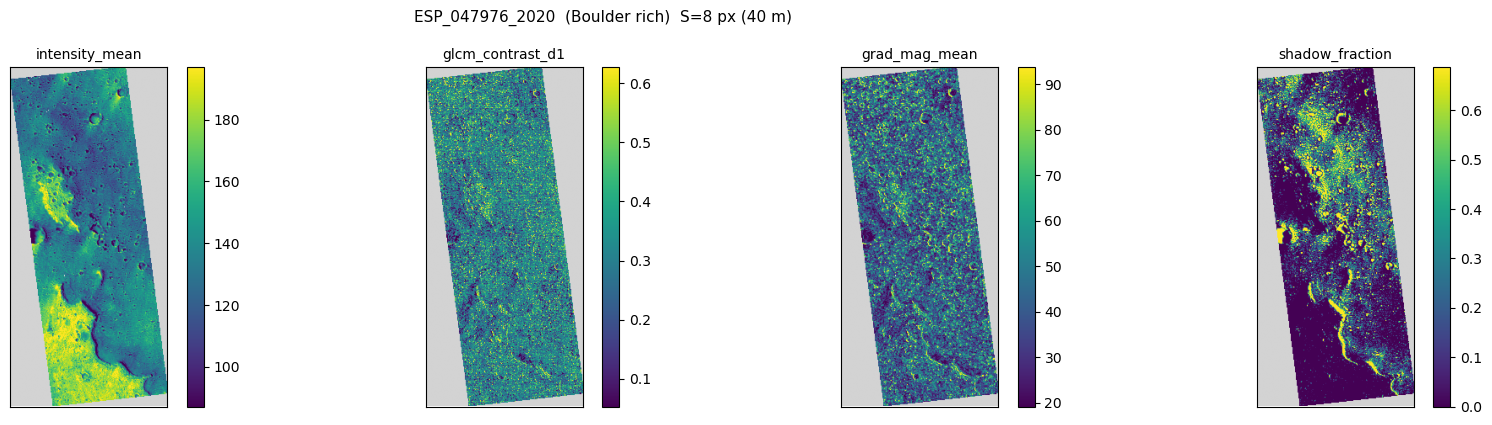

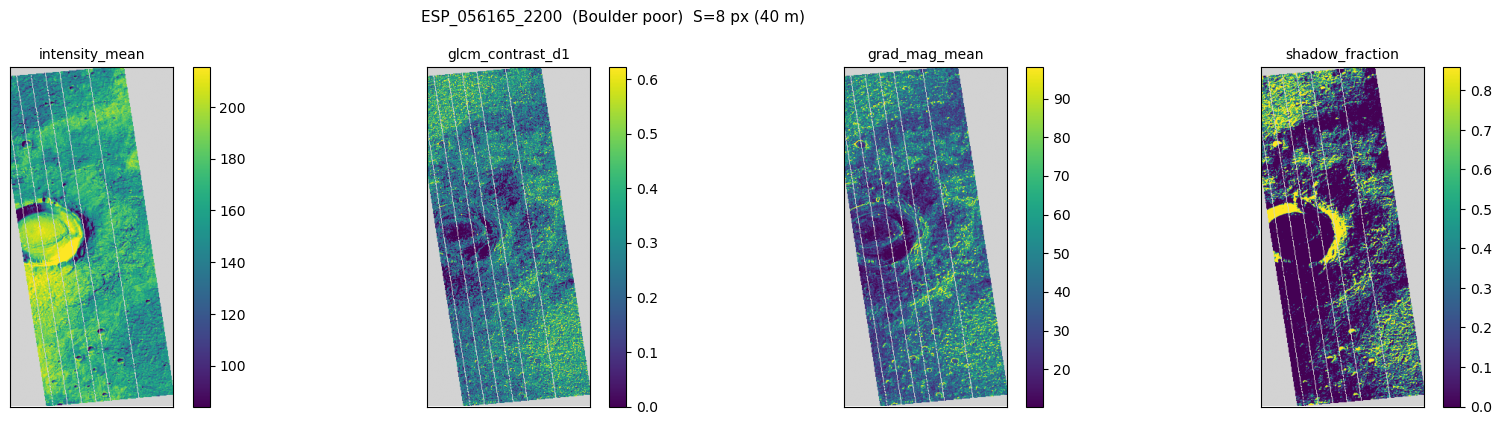

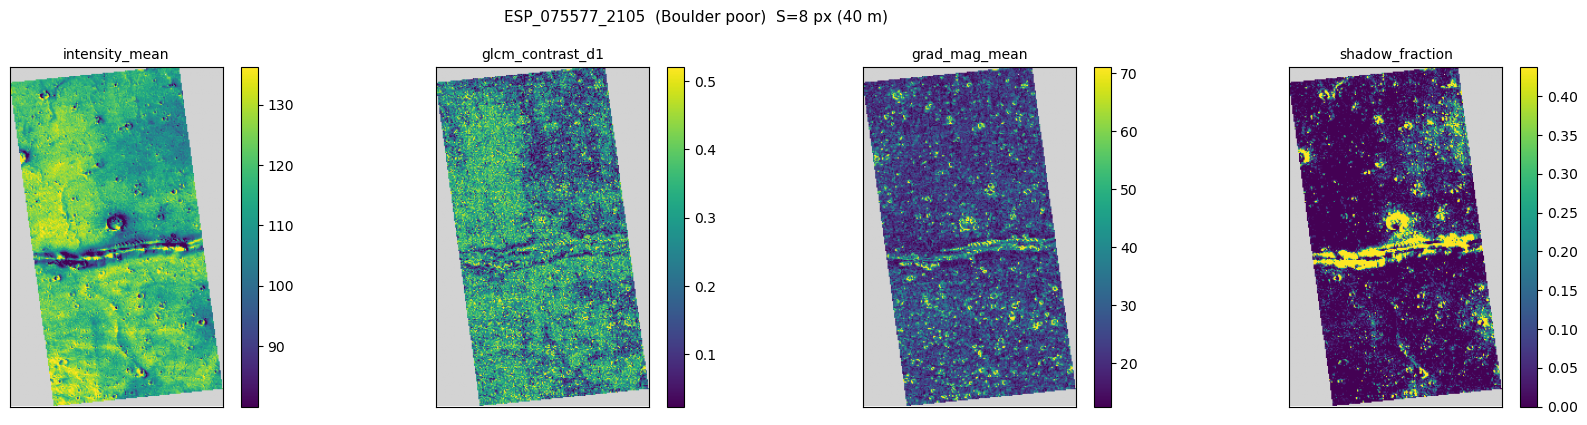

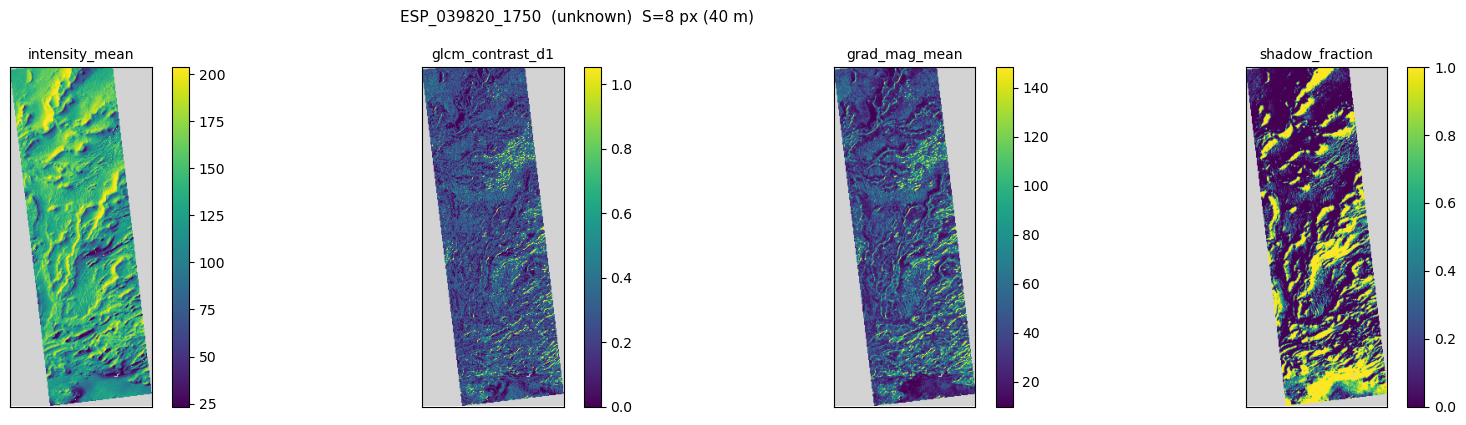

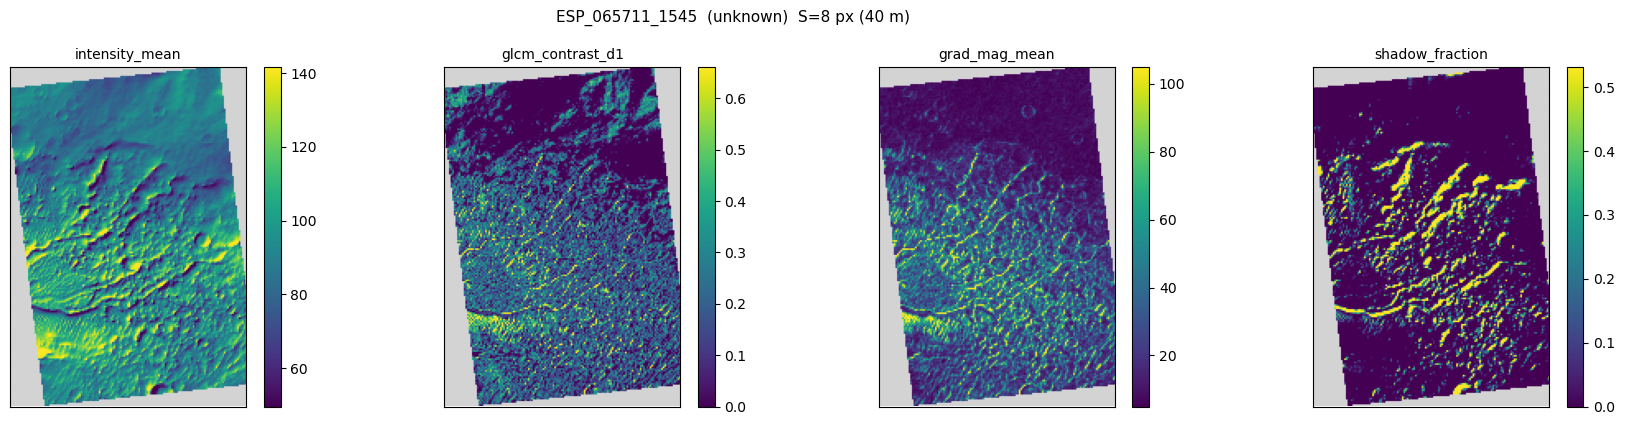

In [4]:
def plot_feature_heatmaps(obs_id):
    feats = load_features(obs_id, cfg.output_dir)
    finest_size = int(feats['tile_size_px'].min())
    sub = feats[feats['tile_size_px'] == finest_size]
    ti_min, ti_max = int(sub['ti'].min()), int(sub['ti'].max())
    tj_min, tj_max = int(sub['tj'].min()), int(sub['tj'].max())
    H = ti_max - ti_min + 1
    W = tj_max - tj_min + 1
    cols = ['intensity_mean', 'glcm_contrast_d1', 'grad_mag_mean', 'shadow_fraction']
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
    for ax, c in zip(axes, cols):
        grid = np.full((H, W), np.nan, dtype=np.float64)
        rs = sub['ti'].to_numpy() - ti_min
        cs = sub['tj'].to_numpy() - tj_min
        grid[rs, cs] = sub[c].to_numpy()
        finite = grid[np.isfinite(grid)]
        if c == 'shadow_fraction':
            vmin, vmax = 0.0, max(float(np.nanpercentile(grid, 95)) if len(finite) else 0.1, 0.05)
        else:
            vmin = float(np.nanpercentile(grid, 1)) if len(finite) else 0.0
            vmax = float(np.nanpercentile(grid, 99)) if len(finite) else 1.0
        cmap = plt.cm.viridis.copy()
        cmap.set_bad(color='lightgrey')
        im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(c, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    label = manifest_df.set_index('ObsId').loc[obs_id, 'BoulderLabel']
    fig.suptitle(f'{obs_id}  ({label})  S={finest_size} px ({finest_size * 5} m)', fontsize=11)
    fig.tight_layout()
    out = FIG_DIR / f'07_heatmaps_{obs_id}.png'
    fig.savefig(out, dpi=100)
    plt.show()
    return out

for obs in obs_ids:
    plot_feature_heatmaps(obs)


## glcm_contrast vs fractional_area, colored by image

Sanity check: GLCM contrast should rise with boulder coverage. Each point is one finest
tile; color = ObsId. Boulder-rich images should sit higher on both axes; boulder-poor
images should cluster near (low_contrast, low_frac). A monotone-ish positive trend across
the cloud is the expected modeling signal.


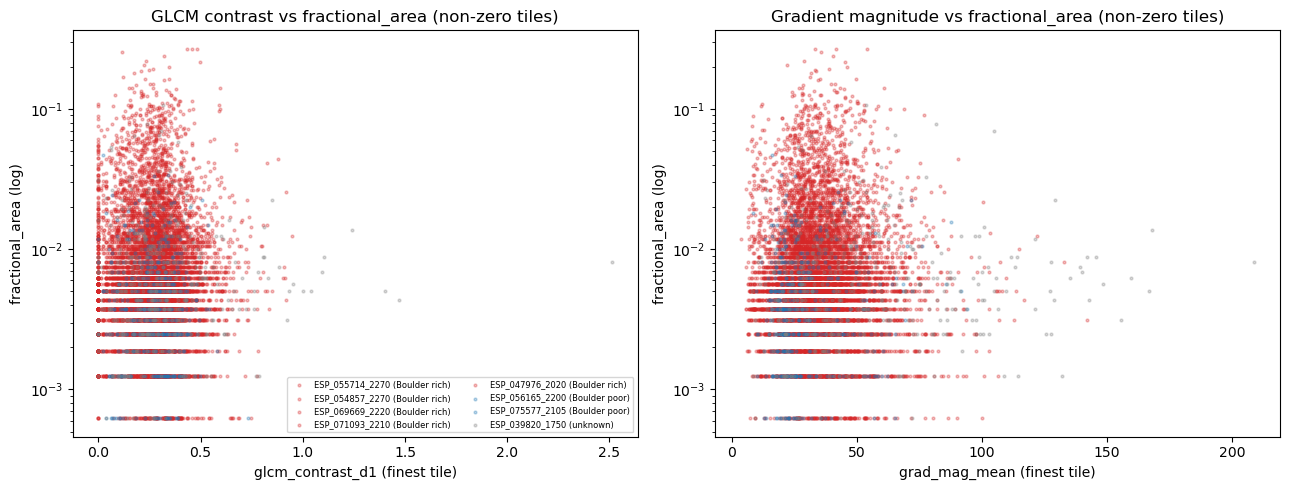

In [5]:
import warnings
joined_parts = []
for obs in obs_ids:
    labels = load_labels(obs, cfg.output_dir)
    feats = load_features(obs, cfg.output_dir)
    df = labels.merge(feats[['obs_id', 'scale_idx', 'tile_size_px', 'ti', 'tj',
                              'glcm_contrast_d1', 'grad_mag_mean', 'shadow_fraction']],
                       on=['obs_id', 'scale_idx', 'tile_size_px', 'ti', 'tj'])
    s_min = int(df['tile_size_px'].min())
    finest = df[df['tile_size_px'] == s_min].copy()
    finest['label'] = manifest_df.set_index('ObsId').loc[obs, 'BoulderLabel']
    joined_parts.append(finest)
joined = pd.concat(joined_parts, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'Boulder rich': 'tab:red', 'Boulder poor': 'tab:blue', 'unknown': 'tab:gray'}
for obs in obs_ids:
    sub = joined[joined['obs_id'] == obs]
    lab = sub['label'].iloc[0]
    nonzero = sub[sub['fractional_area'] > 0]
    if len(nonzero) > 0:
        axes[0].scatter(nonzero['glcm_contrast_d1'], nonzero['fractional_area'],
                        s=4, alpha=0.3, color=colors.get(lab, 'k'), label=f'{obs} ({lab})')
        axes[1].scatter(nonzero['grad_mag_mean'], nonzero['fractional_area'],
                        s=4, alpha=0.3, color=colors.get(lab, 'k'))
axes[0].set_xlabel('glcm_contrast_d1 (finest tile)')
axes[0].set_ylabel('fractional_area (log)')
axes[0].set_yscale('log')
axes[0].set_title('GLCM contrast vs fractional_area (non-zero tiles)')
axes[0].legend(fontsize=6, loc='lower right', ncol=2)
axes[1].set_xlabel('grad_mag_mean (finest tile)')
axes[1].set_ylabel('fractional_area (log)')
axes[1].set_yscale('log')
axes[1].set_title('Gradient magnitude vs fractional_area (non-zero tiles)')
fig.tight_layout()
fig.savefig(FIG_DIR / '07_features_vs_target.png', dpi=110)
plt.show()


## Feature-feature correlation matrix (finest scale)

How redundant are the families? Strong off-block correlations would suggest collapsing
related features before modeling (e.g. if `intensity_p10` and `intensity_min` have r > 0.95,
keep one). Block structure within a family (intensity, GLCM, gradient, ...) is expected.


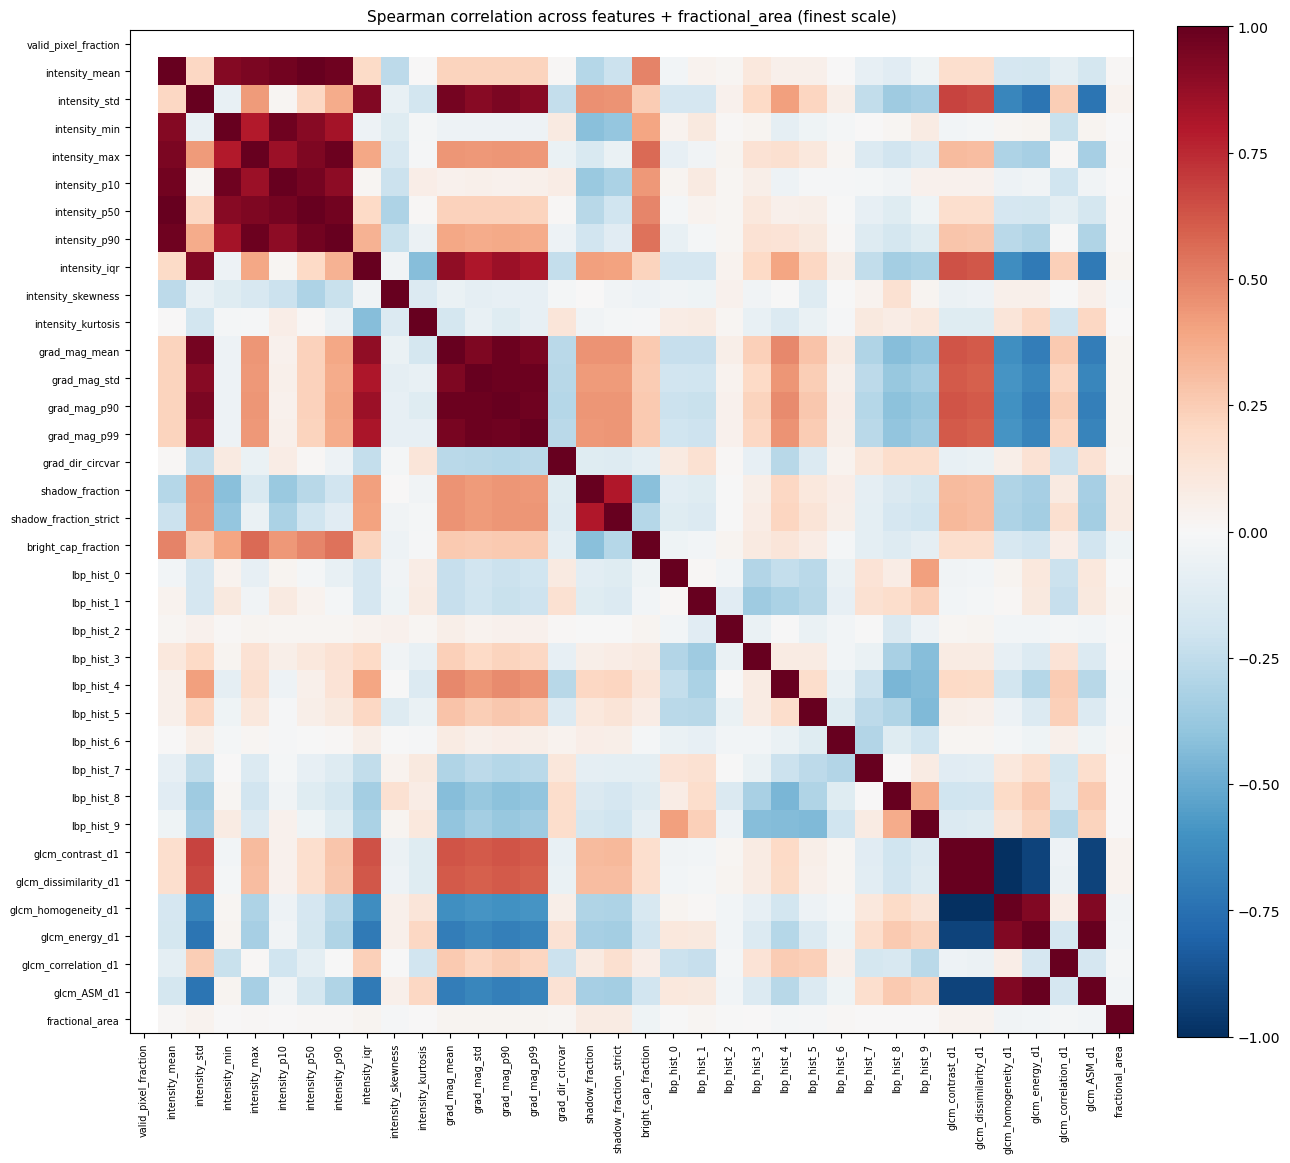

Top 10 positive correlations with fractional_area:
shadow_fraction_strict    0.082621
shadow_fraction           0.079211
intensity_std             0.035062
glcm_contrast_d1          0.033334
glcm_dissimilarity_d1     0.032966
intensity_iqr             0.030527
grad_mag_mean             0.027976
grad_mag_p90              0.026885
grad_mag_p99              0.026417
grad_mag_std              0.025935

Top 10 negative correlations with fractional_area:
lbp_hist_2             -0.005634
lbp_hist_5             -0.011736
intensity_skewness     -0.014173
lbp_hist_4             -0.019454
glcm_correlation_d1    -0.023295
glcm_energy_d1         -0.023951
glcm_ASM_d1            -0.023953
glcm_homogeneity_d1    -0.032906
bright_cap_fraction    -0.040210
valid_pixel_fraction         NaN


In [6]:
# Numeric feature columns at the finest scale only (subtile_var/canny/lacunarity NaN there).
finest = joined[joined['tile_size_px'] == joined['tile_size_px'].min()]
# Pull all numeric feature columns from one image's features parquet to get the right names.
sample = load_features(obs_ids[0], cfg.output_dir)
exclude = {'obs_id', 'scale_idx', 'tile_size_px', 'ti', 'tj', 'config_hash',
           'patch_idx_S32', 'patch_idx_S64'}
feature_cols = [c for c in sample.columns if c not in exclude]

# Re-merge with the larger set of feature columns.
big_join_parts = []
for obs in obs_ids:
    feats = load_features(obs, cfg.output_dir)
    labels = load_labels(obs, cfg.output_dir)
    df = labels[['obs_id', 'scale_idx', 'tile_size_px', 'ti', 'tj', 'fractional_area']].merge(
        feats[['obs_id', 'scale_idx', 'tile_size_px', 'ti', 'tj'] + feature_cols],
        on=['obs_id', 'scale_idx', 'tile_size_px', 'ti', 'tj'],
    )
    big_join_parts.append(df[df['tile_size_px'] == df['tile_size_px'].min()])
big_finest = pd.concat(big_join_parts, ignore_index=True)

# Filter to columns that have any non-NaN values at the finest scale.
finite_cols = [c for c in feature_cols
               if big_finest[c].dropna().shape[0] > 100]
corr = big_finest[finite_cols + ['fractional_area']].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 12))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)
ax.set_title('Spearman correlation across features + fractional_area (finest scale)', fontsize=11)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIG_DIR / '07_feature_correlation_matrix.png', dpi=110)
plt.show()

# Sort feature -> target correlations to surface the strongest signals.
target_corr = corr['fractional_area'].drop('fractional_area').sort_values(ascending=False)
print('Top 10 positive correlations with fractional_area:')
print(target_corr.head(10).to_string())
print()
print('Top 10 negative correlations with fractional_area:')
print(target_corr.tail(10).to_string())


## Context patch sample

A few example context patches at S=32 and S=64 for visual sanity. Each patch is a raw uint8
CTX chip centered on the tile center; the CNN baseline will use these directly.


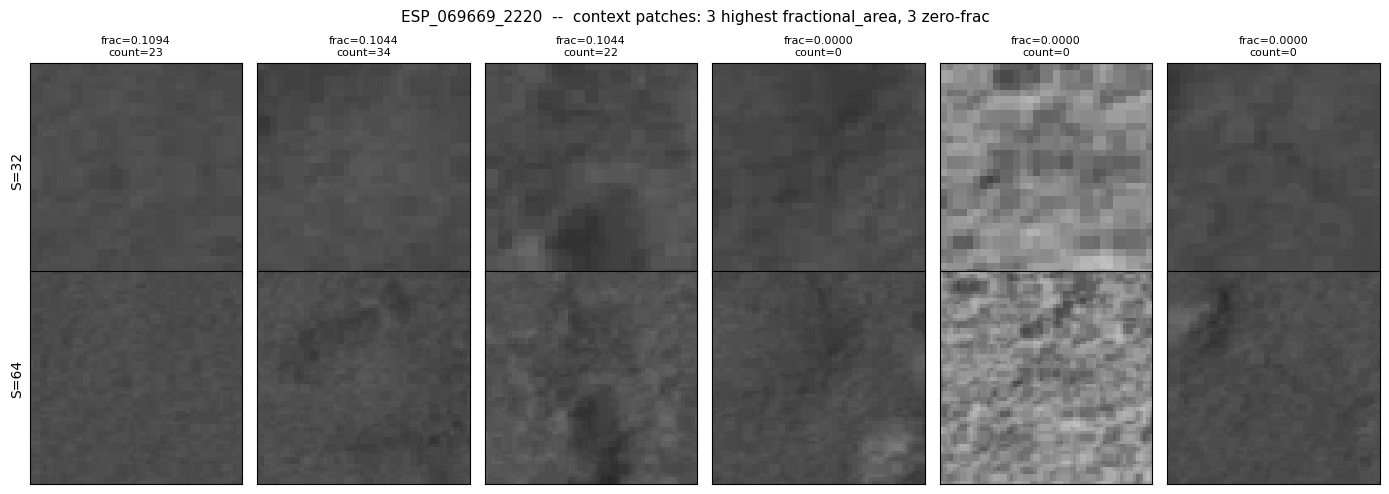

In [7]:
obs_ref = 'ESP_069669_2220' if 'ESP_069669_2220' in obs_ids else obs_ids[0]
feats = load_features(obs_ref, cfg.output_dir)
labels = load_labels(obs_ref, cfg.output_dir)
joined_ref = labels.merge(feats, on=['obs_id', 'scale_idx', 'tile_size_px', 'ti', 'tj'])
finest = joined_ref[joined_ref['tile_size_px'] == joined_ref['tile_size_px'].min()]

# Six sampled patches: 3 highest fractional_area + 3 zero-frac.
high_idx = finest.sort_values('fractional_area', ascending=False).head(3)
zero_idx = finest[finest['fractional_area'] == 0].sample(n=3, random_state=0)
samples = pd.concat([high_idx, zero_idx], ignore_index=True)

patches32 = load_context_patches(obs_ref, 32, cfg.output_dir)
patches64 = load_context_patches(obs_ref, 64, cfg.output_dir)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for col_idx, (_, row) in enumerate(samples.iterrows()):
    idx32 = int(row['patch_idx_S32'])
    idx64 = int(row['patch_idx_S64'])
    if idx32 >= 0:
        axes[0, col_idx].imshow(patches32[idx32], cmap='gray', vmin=0, vmax=255)
    axes[0, col_idx].set_title(f'frac={row["fractional_area"]:.4f}\ncount={int(row["boulder_count"])}',
                                fontsize=8)
    if idx64 >= 0:
        axes[1, col_idx].imshow(patches64[idx64], cmap='gray', vmin=0, vmax=255)
    axes[0, col_idx].set_xticks([]); axes[0, col_idx].set_yticks([])
    axes[1, col_idx].set_xticks([]); axes[1, col_idx].set_yticks([])
axes[0, 0].set_ylabel('S=32', fontsize=10)
axes[1, 0].set_ylabel('S=64', fontsize=10)
fig.suptitle(f'{obs_ref}  --  context patches: 3 highest fractional_area, 3 zero-frac', fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / f'07_patches_{obs_ref}.png', dpi=110)
plt.show()


## Decisions to revisit after looking at the above

- **Feature redundancy**: if `intensity_min` and `intensity_p10` show r > 0.98 across all
  images (likely), pick one. Same for `glcm_dissimilarity` vs `glcm_contrast`.
- **`min_confidence` filter** -- still `null`. With features in hand, modeling-stage feature
  importance can guide whether low-score detections should be filtered out.
- **`shadow_offset_dn`** value (currently 20) -- check the per-image DN-threshold table
  above. If shadow_fraction stays near zero for boulder-rich images at the chosen offset,
  consider lowering to 15. If it saturates near 1 on boulder-poor scenes, raise to 25.
- **GLCM `levels`** at S=8 (currently 8 = highest quantization) -- the
  `glcm_contrast_d1` heatmaps should show clear texture contrast between boulder-rich
  ejecta and smooth plains. If they don't, raising to 16 levels is the next knob.
- **Context patch storage** -- bundled per-(obs, patch_size) `.npy` stacks (not the
  per-tile-file layout from PLAN_Stage4b.md §6; deviation documented in DECISIONS.md).
